### DIABETES DATA ANALYSIS PRACTICAL

### Dataset
Dataset Name: Diabetes Datase

### PART A: DATA LOADING AND INSPECTION

###  Import the necessary Python libraries and load the Diabetes dataset

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df=pd.read_csv(r'c:\Users\Administrator\Desktop\BLECA WEEK 2\diabetes.csv')

### : Display the first 10 records of the dataset

In [44]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### : Display the last 10 records of the dataset

In [45]:
df.tail(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


### Determine the number of rows and columns in the dataset

In [46]:
df.shape

(768, 9)

###  Display all column names in the dataset

In [47]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

### PART B: DATA CLEANING

### Check for missing values in each column.

In [48]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

### : Check whether the dataset contains duplicated records

In [49]:
df.duplicated().sum()

np.int64(0)

### PART C: DATA ANALYSIS

###  Determine the number of diabetic and non-diabetic patients

In [50]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

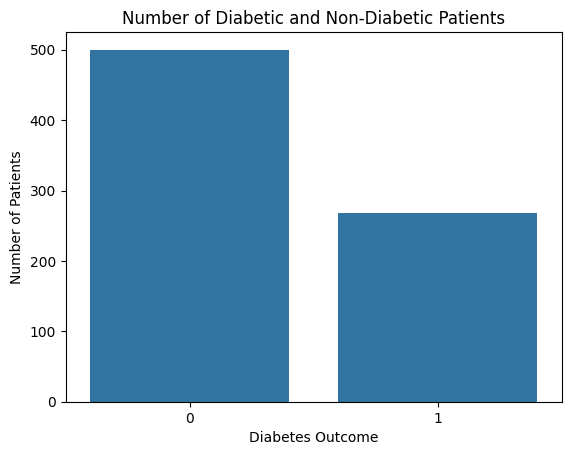

In [51]:
sns.countplot(x="Outcome", data=df)
plt.title("Number of Diabetic and Non-Diabetic Patients")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Patients")
plt.show()

### Determine the average age of diabetic and non-diabetic patients

In [52]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

### Determine the average glucose level for diabetic and non-diabetic patients.

In [53]:
df.groupby("Outcome")["Glucose"].mean()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64

### Determine the average blood pressure for diabetic and non-diabetic patients.


In [54]:
df.groupby("Outcome")["BloodPressure"].mean()

Outcome
0    68.184000
1    70.824627
Name: BloodPressure, dtype: float64

### : Determine which diabetes outcome has the highest average glucose level.

In [55]:
df.groupby("Outcome")["Glucose"].mean().sort_values(ascending=False)

Outcome
1    141.257463
0    109.980000
Name: Glucose, dtype: float64

### Determine which diabetes outcome has the highest average BMI

In [56]:
df.groupby("Outcome")["BMI"].mean().sort_values(ascending=False)

Outcome
1    35.142537
0    30.304200
Name: BMI, dtype: float64

###  Calculate the correlation between all numerical variables

In [57]:
correlation = df.corr(numeric_only=True)
correlation

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


###  correlation heatmap.

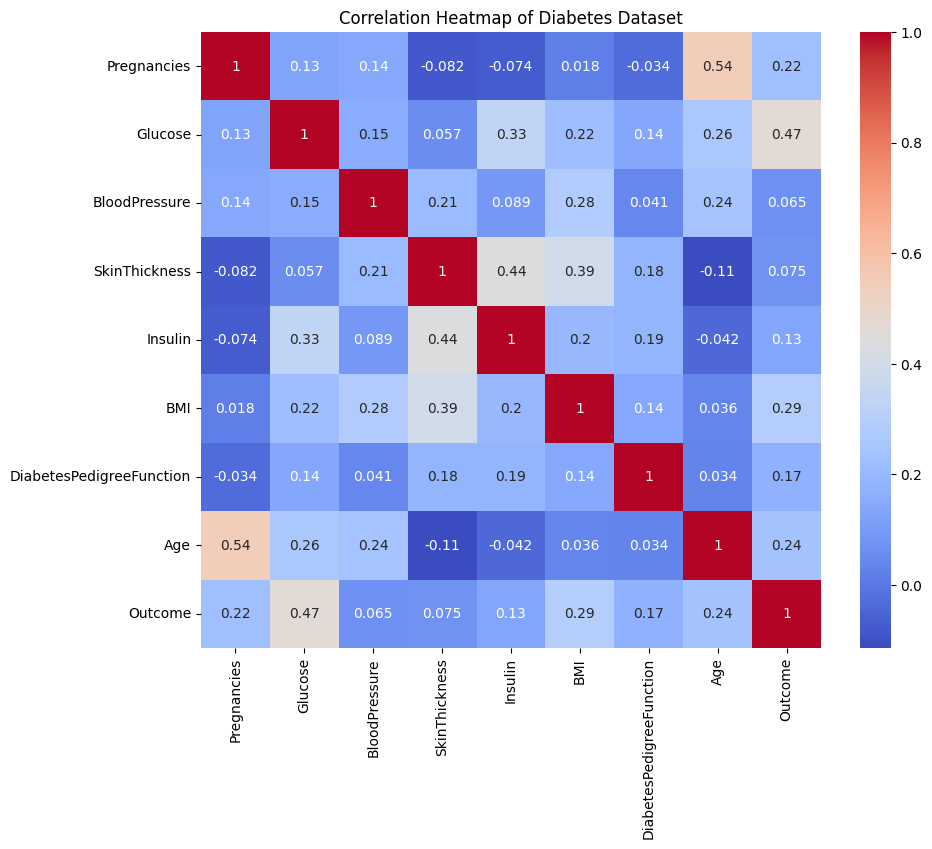

In [58]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

###  Identify the variables that have the strongest correlation with diabetes outcome

In [59]:
correlation_with_outcome = (
    df.corr(numeric_only=True)["Outcome"]
    .sort_values(ascending=False)
)
correlation_with_outcome

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

### OUTLIER ANALYSIS

In [60]:
Q1 = df["Glucose"].quantile(0.25)
Q3 = df["Glucose"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df["Glucose"] < lower_bound) |
    (df["Glucose"] > upper_bound)
]
outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


### : BUSINESS QUESTIONS

 ###  factor appears to contribute most to diabetes prediction

In [65]:
df.iloc[0]

Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                       0.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

###  percentage of patients in the dataset are diabetic


In [66]:
diabetic_percentage = (
    df["Outcome"].mean() * 100
)

print(
    "Percentage of diabetic patients:",
    diabetic_percentage)

Percentage of diabetic patients: 34.89583333333333


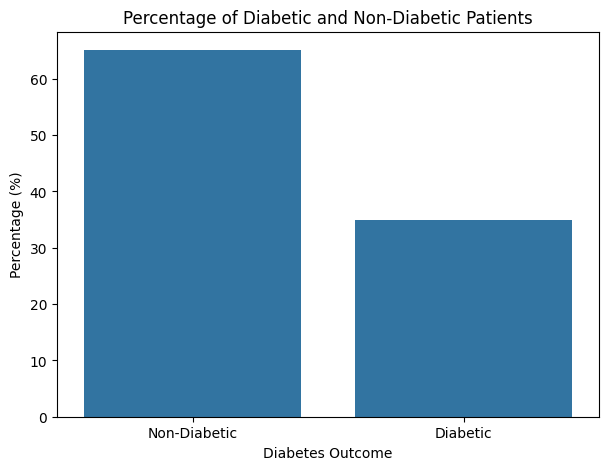

In [82]:
outcome_percentage = df["Outcome"].value_counts(normalize=True) * 100
plt.figure(figsize=(7, 5))
sns.barplot(x=outcome_percentage.index, y=outcome_percentage.values)
plt.title("Percentage of Diabetic and Non-Diabetic Patients")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Percentage (%)")
plt.xticks([0, 1], ["Non-Diabetic", "Diabetic"])
plt.show()

###  the average Glucose level among diabetic patients

In [67]:
average_glucose_diabetic = df[
    df["Outcome"] == 1
]["Glucose"].mean()
print(
    "Average Glucose among diabetic patients:",
    average_glucose_diabetic)

Average Glucose among diabetic patients: 141.25746268656715


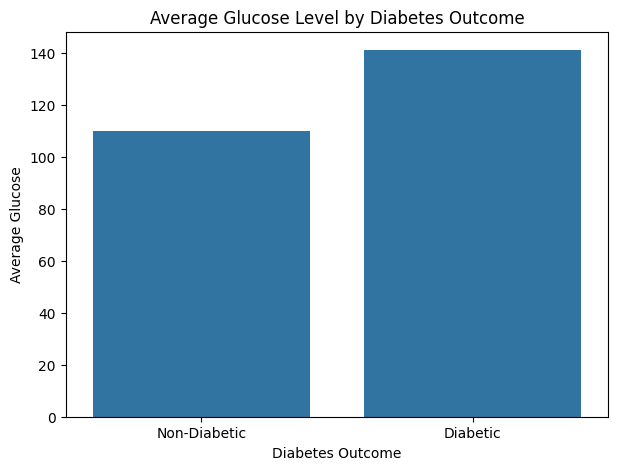

In [83]:
average_glucose = df.groupby("Outcome")["Glucose"].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(x="Outcome", y="Glucose", data=average_glucose)
plt.title("Average Glucose Level by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Average Glucose")
plt.xticks([0, 1], ["Non-Diabetic", "Diabetic"])
plt.show()

### :  the average BMI among diabetic patients

In [68]:
average_bmi_diabetic = df[
    df["Outcome"] == 1
]["BMI"].mean()
print(
    "Average BMI among diabetic patients:",
    average_bmi_diabetic
)

Average BMI among diabetic patients: 35.14253731343284


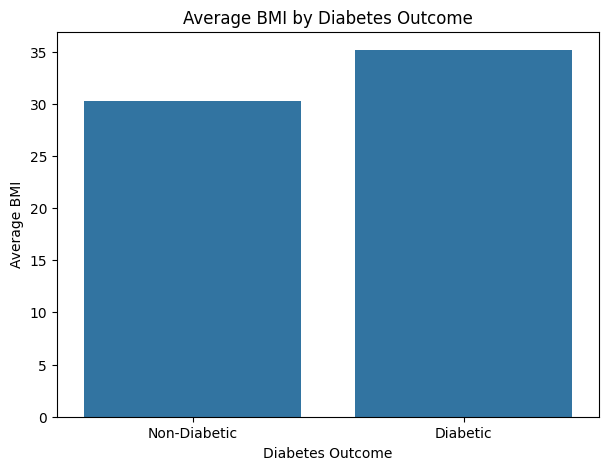

In [81]:
average_bmi = df.groupby("Outcome")["BMI"].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(x="Outcome", y="BMI", data=average_bmi)
plt.title("Average BMI by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Average BMI")
plt.xticks([0, 1], ["Non-Diabetic", "Diabetic"])
plt.show()


### Recommendations Based on Insights


### 1. Glucose: Since glucose is expected to be one of the strongest predictors, patients with elevated glucose levels should receive closer monitoring and appropriate diabetes screening.


### 2. BMI: If the BMI visualization shows higher BMI among      diabetic patients, healthy weight management, balanced nutrition, and regular physical activity should be encouraged.


### 3. Age: If the analysis shows higher diabetes occurrence among older patients, regular diabetes screening should be emphasized for older age groups.


### 4. Pregnancies: If Pregnancies shows a noticeable relationship with Outcome, women with a higher number of pregnancies may benefit from appropriate diabetes-risk monitoring.


### 5. Blood Pressure: Where the analysis indicates differences in blood pressure between groups, blood-pressure monitoring should be considered as part of diabetes-risk assessment.


### 6. Insulin: Insulin patterns should be investigated together with glucose and other metabolic indicators rather than considered independently.


### 7. Diabetes Pedigree Function: If this feature has relatively high importance, patients with stronger hereditary/family-risk indicators should receive appropriate risk assessment and preventive screening.